# **Assessment 12: Introduction to NLP & Text Preprocessing**
## **Members: Carolino, Bryant Kenzo | Lavado, Sean Eldridge | Sy, Eibert Deane**

---

## **Abstract**

This project builds a Natural Language Processing (NLP) pipeline for sentiment analysis on movie reviews. It explores essential text preprocessing steps, directly comparing NLTK's Porter Stemmer against spaCy's Lemmatizer, and applies custom stop-word filtering to remove domain noise. The cleaned text is vectorized into a TF-IDF matrix to extract key positive and negative sentiment phrases (unigrams and bigrams), and document relationships are evaluated and visualized using Cosine Similarity.

---

## **Task 1 — Data Loading & Exploration Understand the dataset before any preprocessing.**

### 1.  Load IMDB Dataset.csv. Print the shape and first 3 rows.

In [1]:
import nltk
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

nltk.download('averaged_perceptron_tagger', quiet=True)
print("All libraries loaded!")

All libraries loaded!


In [19]:
# Load the CSV file
df = pd.read_csv('C:\\Users\\Dell\\Documents\\UST Docs\\Sophomore\\2ND_SEM\\FINALS\\AI\\ass12\\IMDB Dataset.csv')

# Shape
df.shape

(50000, 2)

In [17]:
# First 3 rows
df.head(3)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


### 2. Print the sentiment distribution using value_counts(). Confirm the dataset is balanced.

In [22]:
# 1. Print the distribution of sentiment labels
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


### 3. Compute the average word count per review for each sentiment group. Which group tends to write longer reviews?

In [28]:
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

average_word_counts = df.groupby('sentiment')['word_count'].mean()

print("Average Word Count per Sentiment:")
print(average_word_counts)

longer_reviews_group = average_word_counts.idxmax()

Average Word Count per Sentiment:
sentiment
negative    229.46456
positive    232.84932
Name: word_count, dtype: float64


The *positive* group tends to write longer reviews

### 4. Print 2 sample reviews for each sentiment. Do they read like what you would expect from a movie review?

In [42]:
samples = df.groupby('sentiment').head(1)

for index, row in samples.iterrows():
    print(f"Sentiment: {row['sentiment'].upper()}")
    print(f"Review: {row['review']}")
    print("-" * 40 + "\n")

Sentiment: POSITIVE
Review: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal o

The two sample reviews reads like what you would usually read under streaming sites. The distintion in both of the reviews, however, is that they are both very specific and professional sounding, as to be expected from a review in IMDB. They detail what they saw, how they felt about it, then how other people might find it.

---

## **Task 2 — Text Cleaning & Tokenization Build a reusable cleaning function that handles real messy review text.**

### 1. Write a clean_text(text) function that: (a) lowercases, (b) removes HTML tags using re — this dataset contains <br /> tags, (c) removes punctuation and numbers, (d) strips extra whitespace. Apply it to the review column and store in a cleaned column.

In [47]:
import re
import string

def clean_text(text):
    # (a) Lowercase
    text = text.lower()
    
    # (b) Remove HTML tags (handles <br />, <div>, etc.)
    text = re.sub(r'<.*?>', '', text)
    
    # (c) Remove punctuation and numbers
    text = re.sub(r'[%s\d]' % re.escape(string.punctuation), '', text)
    
    # (d) Strip extra whitespace
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    
    return text

# Apply the function to the 'review' column and store in 'cleaned'
df['cleaned'] = df['review'].apply(clean_text)

# Preview the results
print(df[['review', 'cleaned']].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                             cleaned  
0  one of the other reviewers has mentioned that ...  
1  a wonderful little production the filming tech...  
2  i thought this was a wonderful way to spend ti...  
3  basically theres a family where a little boy j...  
4  petter matteis love in the time of money is a ...  


### 2. Tokenize the cleaned column using nltk.word_tokenize. Remove English stop words. Store the result in a tokens column.

In [59]:
# Define the set of English stop words
stop_words = set(stopwords.words('english'))

def tokenize_and_remove_stopwords(text):
    # 1. Tokenize the cleaned text
    tokens = word_tokenize(text)
    
    # 2. Filter out stop words
    # This keeps only words NOT found in the stop_words set
    filtered_tokens = [word for word in tokens if word not in stop_words]
    
    return filtered_tokens

# Apply the function to the 'cleaned' column
df['tokens'] = df['cleaned'].apply(tokenize_and_remove_stopwords)

# View the result
print(df[['cleaned', 'tokens']].head())

                                             cleaned  \
0  one of the other reviewers has mentioned that ...   
1  a wonderful little production the filming tech...   
2  i thought this was a wonderful way to spend ti...   
3  basically theres a family where a little boy j...   
4  petter matteis love in the time of money is a ...   

                                              tokens  
0  [one, reviewers, mentioned, watching, oz, epis...  
1  [wonderful, little, production, filming, techn...  
2  [thought, wonderful, way, spend, time, hot, su...  
3  [basically, theres, family, little, boy, jake,...  
4  [petter, matteis, love, time, money, visually,...  


### 3. Print the 20 most frequent tokens overall. Do any tokens seem too generic for sentiment analysis (e.g., film, movie, one)? Add at least 3 to a custom stop word list and re-filter.

In [62]:
from collections import Counter

all_tokens = [token for sublist in df['tokens'] for token in sublist]

# Count frequencies
word_freq = Counter(all_tokens)

# Print the 20 most common
print("Top 20 tokens before custom filtering:")
for word, count in word_freq.most_common(20):
    print(f"{word}: {count}")

Top 20 tokens before custom filtering:
movie: 83577
film: 74519
one: 50394
like: 38833
good: 28502
even: 24284
would: 24001
time: 23298
really: 22900
see: 22437
story: 22063
much: 18897
well: 18462
get: 18184
great: 17723
bad: 17672
also: 17491
people: 17486
first: 16839
dont: 16588


In [64]:
# Define custom stop words
custom_stops = {'movie', 'film', 'one', 'like', 'really'} # Added a couple more common ones

# Update the main stop_words set
stop_words.update(custom_stops)

df['tokens'] = df['tokens'].apply(lambda x: [word for word in x if word not in stop_words])

# Check the top 20 again
new_all_tokens = [token for sublist in df['tokens'] for token in sublist]
new_word_freq = Counter(new_all_tokens)

print("\nTop 20 tokens after custom filtering:")
for word, count in new_word_freq.most_common(20):
    print(f"{word}: {count}")


Top 20 tokens after custom filtering:
good: 28502
even: 24284
would: 24001
time: 23298
see: 22437
story: 22063
much: 18897
well: 18462
get: 18184
great: 17723
bad: 17672
also: 17491
people: 17486
first: 16839
dont: 16588
movies: 15447
made: 15414
films: 15288
make: 15284
could: 15143


### 4. Show a before-and-after table for 3 reviews: original review → cleaned → final tokens.

In [69]:
pd.set_option('display.max_colwidth', None)

before_after_df = df[['review', 'cleaned', 'tokens']].head(3)

display(before_after_df)

,review,cleaned,tokens
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awayi would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty pictures painted for mainstream audiences forget charm forget romanceoz doesnt mess around the first episode i ever saw struck me as so nasty it was surreal i couldnt say i was ready for it but as i watched more i developed a taste for oz and got accustomed to the high levels of graphic violence not just violence but injustice crooked guards wholl be sold out for a nickel inmates wholl kill on order and get away with it well mannered middle class inmates being turned into prison bitches due to their lack of street skills or prison experience watching oz you may become comfortable with what is uncomfortable viewingthats if you can get in touch with your darker side,"[reviewers, mentioned, watching, oz, episode, youll, hooked, right, exactly, happened, methe, first, thing, struck, oz, brutality, unflinching, scenes, violence, set, right, word, go, trust, show, faint, hearted, timid, show, pulls, punches, regards, drugs, sex, violence, hardcore, classic, use, wordit, called, oz, nickname, given, oswald, maximum, security, state, penitentary, focuses, mainly, emerald, city, experimental, section, prison, cells, glass, fronts, face, inwards, privacy, high, agenda, em, city, home, manyaryans, muslims, gangs

---

## **Task 3 — Stemming vs. Lemmatization Compare normalization approaches on review language.**

### 1. Take a random sample of 300 reviews (random_state=42). Apply Porter Stemming to the tokens. Store in a stemmed column.

In [72]:
from nltk.stem import PorterStemmer

# Take a random sample of 300 reviews
df_sample = df.sample(n=300, random_state=42).copy()

# Initialize the Porter Stemmer
stemmer = PorterStemmer()

# Define a function to stem the list of tokens
def stem_tokens(token_list):
    return [stemmer.stem(word) for word in token_list]

# Apply to the tokens column and store in 'stemmed'
df_sample['stemmed'] = df_sample['tokens'].apply(stem_tokens)

# View the results
print(df_sample[['tokens', 'stemmed']].head())

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 tokens  \
33553                                                                                                                   [liked, summerslam, d

### 2. Apply spaCy Lemmatization to the same sample. Store in a lemmatized column.

In [79]:
import subprocess
import spacy

subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"], check=True)

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

print("\n=== Detailed spaCy Analysis for Sample Review ===")
sample_text = " ".join(df_sample['tokens'].iloc[0]) # Grab the first list of tokens and join them
doc = nlp(sample_text)

print(f"{'Token':<15} {'Lemma':<15} {'POS':<10} {'Is Stop?':<10}")
print("-" * 50)
# Showing just the first 10 tokens to keep the output clean
for token in list(doc)[:10]:
    print(f"{token.text:<15} {token.lemma_:<15} {token.pos_:<10} {str(token.is_stop):<10}")

def lemmatize_tokens(token_list):
    doc = nlp(" ".join(token_list))
    return [token.lemma_ for token in doc]

# Apply it to the sample and store in the 'lemmatized' column
print("\nApplying lemmatization to the dataframe...")
df_sample['lemmatized'] = df_sample['tokens'].apply(lemmatize_tokens)

print("\n=== Final DataFrame Preview ===")
display(df_sample[['tokens', 'stemmed', 'lemmatized']].head())


=== Detailed spaCy Analysis for Sample Review ===
Token           Lemma           POS        Is Stop?  
--------------------------------------------------
liked           like            VERB       False     
summerslam      summerslam      NOUN       False     
due             due             ADJ        True      
look            look            VERB       False     
arena           arena           NOUN       False     
curtains        curtain         NOUN       False     
look            look            VERB       False     
overall         overall         ADJ        False     
interesting     interesting     ADJ        False     
reason          reason          NOUN       False     

Applying lemmatization to the dataframe...

=== Final DataFrame Preview ===


,tokens,stemmed,lemmatized
33553,"[liked, summerslam, due, look, arena, curtains, look, overall, interesting, reason, anyways, could, best, summerslams, ever, wwf, didnt, lex, luger, main, event, yokozuna, time, ok, huge, fat, man, vs, strong, man, im, glad, times, changed, terrible, main, event, every, match, luger, terrible, matches, card, razor, ramon, vs, ted, dibiase, steiner, brothers, vs, heavenly, bodies, shawn, michaels, vs, curt, hening, event, shawn, named, big, monster, body, guard, diesel, irs, vs, kid, bret, hart, first, takes, doink, takes, jerry, lawler, stuff, harts, lawler, always, interesting, ludvig, borga, destroyed, marty, jannetty, undertaker, took, giant, gonzalez, another, terrible, match, smoking, gunns, tatanka, took, bam, bam, ...]","[like, summerslam, due, look, arena, curtain, look, overal, interest, reason, anyway, could, best, summerslam, ever, wwf, didnt, lex, luger, main, event, yokozuna, time, ok, huge, fat, man, vs, strong, man, im, glad, time, chang, terribl, main, event, everi, match, luger, terribl, match, card, razor, ramon, vs, ted, dibias, steiner, brother, vs, heavenli, bodi, shawn, michael, vs, curt, hene, event, shawn, name, big, monster, bodi, guard, diesel, ir, vs, kid, bret, hart, first, take, doink, take, jerri, lawler, stuff, hart, lawler, alway, interest, ludvig, borga, destroy, marti, jannetti, undertak, took, giant, gonzalez, anoth, terribl, match, smoke, gunn, tatanka, took, bam, bam, ...]","[like, summerslam, due, look, arena, curtain, look, overall, interesting, reason, anyways, could, good, summerslam, ever, wwf, do, not, lex, luger, main, event, yokozuna, time, ok, huge, fat, man, vs, strong, man, I, m, glad, time, change, terrible, main, event, every, match, luger, terrible, match, card, razor, ramon, vs, ted, dibiase, steiner, brother, vs, heavenly, body, shawn, michael, vs, curt, hene, event, shawn, name, big, monster, body, guard, diesel, irs, vs, kid, bret, hart, first, take, doink, take, jerry, lawler, stuff, hart, lawler, always, interesting, ludvig, borga, destroy, marty, jannetty, undertaker, take, giant, gonzalez, another, terrible, match, smoking, gunn, tatanka, take, ...]"
9427,"[many, television, shows, appeal, quite, many, different, kinds, fans, farscape, doesi, know, youngsters, years, oldfans, male, female, many, different, countries, think, adore, tv, miniseries, elements, found, almost, every, show, tv, character, driven, drama, could, australian, soap, opera, yet, episode, science, fact, fiction, would, give, even, hardiest, trekkie, run, money, brainbender, stakes, wormhole, theory, time, travel, true, equational, formmagnificent, embraces, cultures, map, possibilities, endless, multiple, stars, therefore, thousands, planets, choose, fromwith, broad, scope, would, expected, nothing, would, able, keep, illusion, long, farscape, comes, elementit, succeeds, others, failed, especially, likes, star, trek, universe, practically, zero, kaos, element, ran, ideas, pretty, quickly, kept, ...]","[mani, televis, show, appeal, quit, mani, differ, kind, fan, farscap, doesi, know, youngster, year, oldfan, male, femal, mani, differ, countri, think, ador, tv, miniseri, element, found, almost, everi, show, tv, charact, driven, drama, could, australian, soap, opera, yet, episod, scienc, fact, fiction, would, give, even, hardiest, trekki, run, money, brainbend, stake, wormhol, theori, time, travel, true, equat, formmagnific, embrac, cultur, map, possibl, endless, multipl, star, therefor, thousand, planet, choos, fromwith, broad, scope, would, expect, noth, would, abl, keep, illus, long, farscap, come, elementit, succe, other, fail, especi, like, star, trek, univers, practic, zero, kao, element, ran, idea, pretti, quickli, kept, ...]","[many, television, show, appeal, quite, many, different, kind, fan, farscape, doesi, know, youngster, year, oldfans, male, female, many, different, country, think, adore, tv, miniserie, element, find, almost, every, show, tv, character, d

### 3. Build a comparison table of at least 10 words where stemming and lemmatization produce different outputs

In [82]:
stemmer = PorterStemmer()
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

dataset_words = [
    "went", "best", "found", "women", "bodies", 
    "countries", "possibilities", "terrible", "quickly", "convincing"
]

results = []
for word in dataset_words:
    # Get the stem
    stemmed_word = stemmer.stem(word)
    
    # Get the lemma
    lemmatized_word = nlp(word)[0].lemma_
    
    # Append to our list
    results.append({
        "Original Token": word,
        "Porter Stemmer": stemmed_word,
        "spaCy Lemma": lemmatized_word
    })

comparison_df = pd.DataFrame(results)

print("=== Stemming vs. Lemmatization (Dataset Examples) ===")
display(comparison_df)

=== Stemming vs. Lemmatization (Dataset Examples) ===


,Original Token,Porter Stemmer,spaCy Lemma
0,went,went,go
1,best,best,well
2,found,found,find
3,women,women,woman
4,bodies,bodi,body
5,countries,countri,country
6,possibilities,possibl,possibility
7,terrible,terribl,terrible
8,quickly,quickli,quickly
9,convincing,convinc,convince


### 4. Movie reviews use strong evaluative language — words like "amazing", "terrible", "worst", "loved". Does stemming or lemmatization preserve these sentiment-carrying words better? Explain in 2–3 sentences.

Stemming preserves, or tries to preserve, the original sentiment from the review. It maintain *best*, and *terrible*, for example. On the other hand, Lemmatization transforms *best* into *well*.

---

## **Task 4 — TF-IDF Vectorization & Top Terms per Sentiment Find the most distinctive words that separate positive from negative reviews.**

### 1. Using your 300-review sample, apply clean_text() and join the filtered tokens back into strings. Build a TF-IDF matrix using TfidfVectorizer(max_features=500, ngram_range=(1,2)). Print the matrix shape.

In [88]:
from sklearn.feature_extraction.text import TfidfVectorizer

df_sample['processed_text'] = df_sample['lemmatized'].apply(lambda x: ' '.join(x))

tfidf_vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1, 2))

tfidf_matrix = tfidf_vectorizer.fit_transform(df_sample['processed_text'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (300, 500)


### 2. For each sentiment label (positive, negative), print the top 10 TF-IDF terms by averaging TF-IDF scores across all documents in that group.

In [91]:
feature_names = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

tfidf_df['sentiment'] = df_sample['sentiment'].values

grouped_tfidf = tfidf_df.groupby('sentiment').mean()

for sentiment in ['positive', 'negative']:
    print(f"=== Top 10 terms for {sentiment.upper()} reviews ===")
    
    top_10 = grouped_tfidf.loc[sentiment].sort_values(ascending=False).head(10)
    
    for term, score in top_10.items():
        print(f"{term:<15} {score:.4f}")
    print("-" * 35)

=== Top 10 terms for POSITIVE reviews ===
not             0.0543
see             0.0520
well            0.0509
good            0.0492
show            0.0479
make            0.0475
love            0.0417
do              0.0415
watch           0.0413
great           0.0405
-----------------------------------
=== Top 10 terms for NEGATIVE reviews ===
not             0.0744
bad             0.0683
make            0.0653
see             0.0582
even            0.0478
do              0.0466
do not          0.0442
would           0.0438
get             0.0424
watch           0.0419
-----------------------------------


### 3. Identify at least one bigram in the top terms per sentiment and explain why it captures meaning better than its individual words alone (e.g., "special effects" vs. "special" and "effects" separately).

In [96]:
bigram_features = [term for term in grouped_tfidf.columns if ' ' in term]

bigram_tfidf = grouped_tfidf[bigram_features]

for sentiment in ['positive', 'negative']:
    print(f"=== Top 5 Bigrams for {sentiment.upper()} reviews ===")
    
    # Sort the bigrams for the current sentiment
    top_bigrams = bigram_tfidf.loc[sentiment].sort_values(ascending=False).head(5)
    
    for term, score in top_bigrams.items():
        print(f"{term:<20} {score:.4f}")
    print("-" * 40 + "\n")

=== Top 5 Bigrams for POSITIVE reviews ===
do not               0.0377
be not               0.0121
have not             0.0118
new york             0.0113
can not              0.0110
----------------------------------------

=== Top 5 Bigrams for NEGATIVE reviews ===
do not               0.0442
be not               0.0297
can not              0.0169
ever see             0.0167
ve see               0.0146
----------------------------------------



These Bigrams captures meaning better because of the attached negation to the word. For example, *not* alone does not provide much. It can either be *do not, be not, have not*, etc.

### 4. Do the top positive and negative terms match your intuition about what makes a good or bad movie review? Discuss briefly.

Yes. The top terms for POSITIVE reviews include *love*, *great*, *good* (among others), and they're terms I would generally use when evaluating a movie I liked. And the same goes for the terms found in the NEGATIVE reviews.

---

## **Task 5 — Document Similarity Use cosine similarity to find reviews that talk about the same things.**

### 1. Using the TF-IDF matrix from Task 4, compute the cosine similarity matrix using cosine_similarity from sklearn.

In [104]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute the cosine similarity matrix
cosine_sim_matrix = cosine_similarity(tfidf_matrix)

print("Cosine Similarity Matrix Shape:", cosine_sim_matrix.shape)

print("\nTop-Left 5x5 corner of the similarity matrix:")
print(pd.DataFrame(cosine_sim_matrix[:5, :5]))

Cosine Similarity Matrix Shape: (300, 300)

Top-Left 5x5 corner of the similarity matrix:
          0         1         2         3         4
0  1.000000  0.034865  0.038345  0.017833  0.060182
1  0.034865  1.000000  0.165115  0.051504  0.149303
2  0.038345  0.165115  1.000000  0.025811  0.084052
3  0.017833  0.051504  0.025811  1.000000  0.048626
4  0.060182  0.149303  0.084052  0.048626  1.000000


### 2. Pick one negative review from your sample. Find its top 3 most similar reviews (excluding itself). Print each review's first 150 characters and sentiment. Are they also negative?

In [107]:
df_aligned = df_sample.reset_index(drop=True)

target_idx = (df_aligned['sentiment'] == 'negative').idxmax()

print("=== TARGET REVIEW ===")
print(f"Sentiment: {df_aligned['sentiment'].iloc[target_idx].upper()}")
print(f"Text: {df_aligned['review'].iloc[target_idx][:150]}...\n")

# Grab the similarity scores for just this one review
sim_scores = cosine_sim_matrix[target_idx]

# Sort the scores to find the highest ones
top_3_indices = np.argsort(sim_scores)[::-1][1:4]

print("=== TOP 3 MOST SIMILAR REVIEWS ===")
for rank, idx in enumerate(top_3_indices, 1):
    score = sim_scores[idx]
    sentiment = df_aligned['sentiment'].iloc[idx]
    text = df_aligned['review'].iloc[idx][:150]
    
    print(f"Rank {rank} (Similarity Score: {score:.4f})")
    print(f"Sentiment: {sentiment.upper()}")
    print(f"Text: {text}...\n")

=== TARGET REVIEW ===
Sentiment: NEGATIVE
Text: The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy hijacking Steven Seagal would hav...

=== TOP 3 MOST SIMILAR REVIEWS ===
Rank 1 (Similarity Score: 0.2699)
Sentiment: NEGATIVE
Text: My girlfriend and I are really into cheesy horror flicks. Especially ones with lots of unnecessary nudity. When we saw the box cover for this movie at...

Rank 2 (Similarity Score: 0.2588)
Sentiment: NEGATIVE
Text: This is one of the silliest movies I have ever had the misfortune to watch! I should have expected it, after seeing the first two, but I keep getting ...

Rank 3 (Similarity Score: 0.2496)
Sentiment: POSITIVE
Text: Sunday would not be Sunday without an action movie, and when you want intense combat, you turn to Tom Berenger (Platoon).<br /><br />Here he plays a s...



The reviews most similar to the target review all share the same sentiment: **NEGATIVE**

### 3. Pick one positive review and repeat.

In [115]:
df_aligned = df_sample.reset_index(drop=True)

target_idx = (df_aligned['sentiment'] == 'positive').idxmax()

print("=== TARGET REVIEW ===")
print(f"Sentiment: {df_aligned['sentiment'].iloc[target_idx].upper()}")
print(f"Text: {df_aligned['review'].iloc[target_idx][:150]}...\n")

# Grab the similarity scores for just this one review
sim_scores = cosine_sim_matrix[target_idx]

# Sort the scores to find the highest ones
top_3_indices = np.argsort(sim_scores)[::-1][1:4]

print("=== TOP 3 MOST SIMILAR REVIEWS ===")
for rank, idx in enumerate(top_3_indices, 1):
    score = sim_scores[idx]
    sentiment = df_aligned['sentiment'].iloc[idx]
    text = df_aligned['review'].iloc[idx][:150]
    
    print(f"Rank {rank} (Similarity Score: {score:.4f})")
    print(f"Sentiment: {sentiment.upper()}")
    print(f"Text: {text}...\n")

=== TARGET REVIEW ===
Sentiment: POSITIVE
Text: I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, th...

=== TOP 3 MOST SIMILAR REVIEWS ===
Rank 1 (Similarity Score: 0.2365)
Sentiment: NEGATIVE
Text: This was amongst the worst films I have ever encountered. The cinematography was dull, with long tedious shots (like a camera on a tripod filming a st...

Rank 2 (Similarity Score: 0.2354)
Sentiment: NEGATIVE
Text: I was browsing through the movies on demand and saw Underdog for free and it was only 82 minutes long so I decided to watch it. I wasn't expecting muc...

Rank 3 (Similarity Score: 0.2196)
Sentiment: NEGATIVE
Text: May Contain Spoilers.<br /><br />An innocent trailer park or maybe 'Compton' LA white kid witnesses a terrible childhood tragedy relating to drugs and...



The reviews most similar to the target review do not share the same sentiment as it.

### 4. Plot a heatmap of the cosine similarity matrix using seaborn (cmap='RdYlGn', no annotations). Color the y-axis tick labels red for negative and green for positive. Add a proper title.

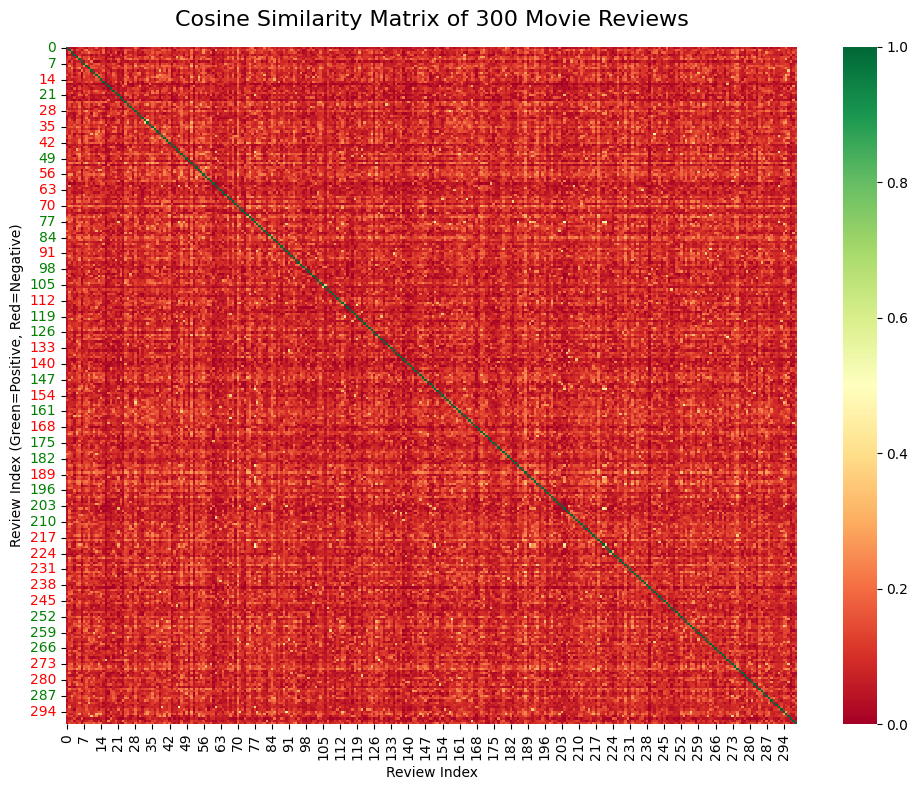

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

ax = sns.heatmap(cosine_sim_matrix, cmap='RdYlGn', annot=False)

plt.title("Cosine Similarity Matrix of 300 Movie Reviews", fontsize=16, pad=15)
plt.xlabel("Review Index")
plt.ylabel("Review Index (Green=Positive, Red=Negative)")

sentiments = df_sample['sentiment'].values

for tick in ax.get_yticklabels():
    try:
        idx = int(tick.get_text())
        
        if sentiments[idx] == 'positive':
            tick.set_color('green')
        else:
            tick.set_color('red')
    except ValueError:
        pass

plt.tight_layout()
plt.show()

---